In [157]:
from fredapi import Fred
import yfinance as yf
import pandas_datareader.data as web

import pandas as pd
import numpy as np

import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

# !pip install pingouin
import pingouin as pg
from statsmodels.tsa.stattools import acf

import importlib
import backtester
importlib.reload(backtester)

from backtester import Backtester
from backtester import Strategy
from backtester import DataHandler
# import Ruff
# import Black
# import MyPy

# Backtesting

* example strategy: buy Gold when 20 day moving average > 60 day moving average
* backtest: check Gold's prices in the past and trade under condition
* results: show if the trades were profitable

[*********************100%***********************]  1 of 1 completed


Final Portfolio Value: 13999.01
Total Return: 39.99%
Annualized Return: 40.37%
Annualized Volatility: 22.55%
Sharpe Ratio: 1.70
Sortino Ratio: 1.84
Maximum Drawdown: -15.62%


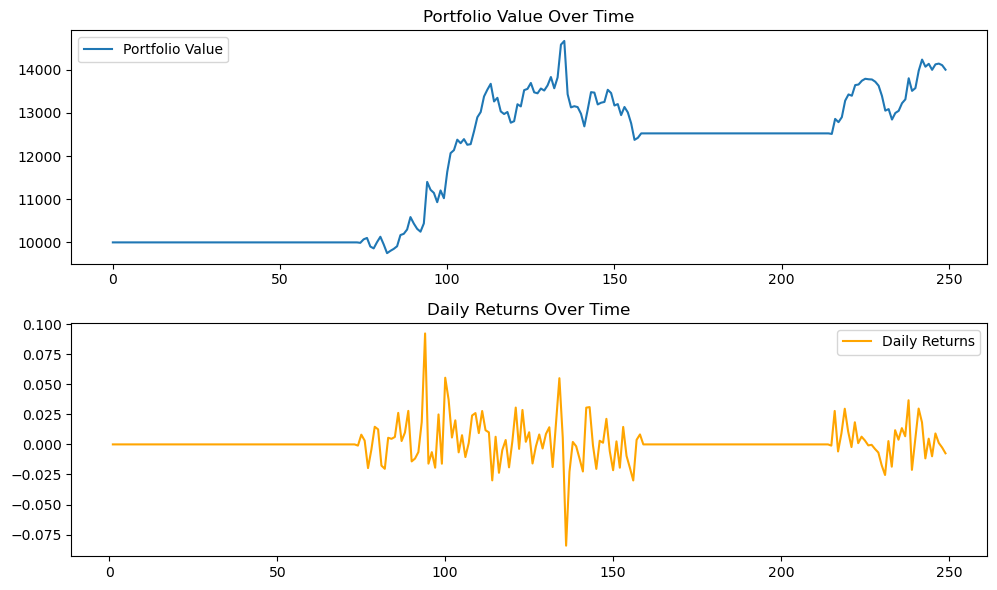

In [155]:

symbols = ["NFLX"]
start_date = "2023-01-01"
end_date = "2023-12-31"

data = yf.download(symbols,start=start_date,end=end_date,auto_adjust=True)['Close']
close_name = ['close' for x in data.columns]
data.columns = close_name

# Define your strategy, indicators, and signal logic here
strategy = Strategy(
    indicators={
        "sma_20": lambda df: df["close"].rolling(window=20).mean(),
        "sma_60": lambda df: df["close"].rolling(window=60).mean(),
    },
    signal_logic=lambda row: 1 if row["sma_20"] > row["sma_60"] else -1,
)

data = strategy.generate_signals(data)
backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()


In [148]:
symbol = "HE"
start_date = "2022-01-01"
end_date = "2022-12-31"

data = yf.download(symbol,start=start_date,end=end_date,auto_adjust=True)['Close']
close_name = ['close' for x in data.columns]
data.columns = close_name

[*********************100%***********************]  1 of 1 completed


Final Portfolio Value: 11902.13
Total Return: 19.02%
Annualized Return: 19.10%
Annualized Volatility: 13.35%
Sharpe Ratio: 1.28
Sortino Ratio: 1.38
Maximum Drawdown: -7.19%


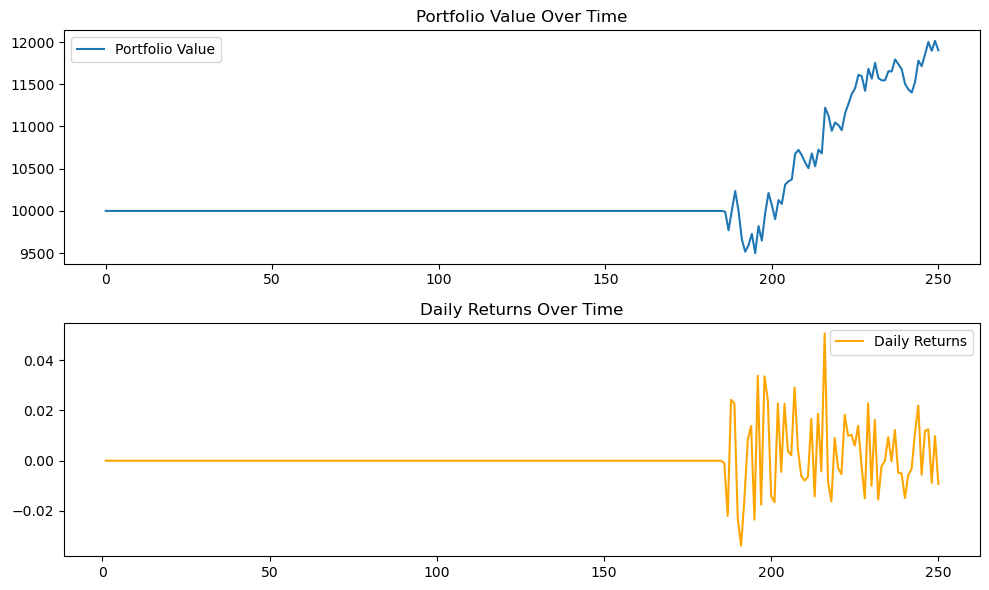

In [ ]:
# Define your strategy, indicators, and signal logic here


strategy = Strategy(
    indicators={
        "sma_50": lambda df: df["close"].rolling(window=50).mean(),
        "std_3": lambda df: df["sma_50"].std() * 3,
        "std_3_upper": lambda df: df["sma_50"] + df["std_3"],
        "std_3_lower": lambda df: df["sma_50"] - df["std_3"],
    },
    signal_logic=lambda df: (
        1
        if df["close"] < df["std_3_lower"]
        else -1 if df["close"] > df["std_3_upper"] else 0
    ),
)


data = strategy.generate_signals(data)

backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()

In [187]:
tickers = ["NFLX","ROKU"]
start_date = "2023-01-01"
end_date = "2024-04-03"

data = yf.download(tickers,start=start_date,end=end_date,auto_adjust=True)['Close']

[*********************100%***********************]  2 of 2 completed


Final Portfolio Value: 14546.13
Total Return: 45.46%
Annualized Return: 35.22%
Annualized Volatility: 67.80%
Sharpe Ratio: 0.49
Sortino Ratio: 0.77
Maximum Drawdown: -42.20%


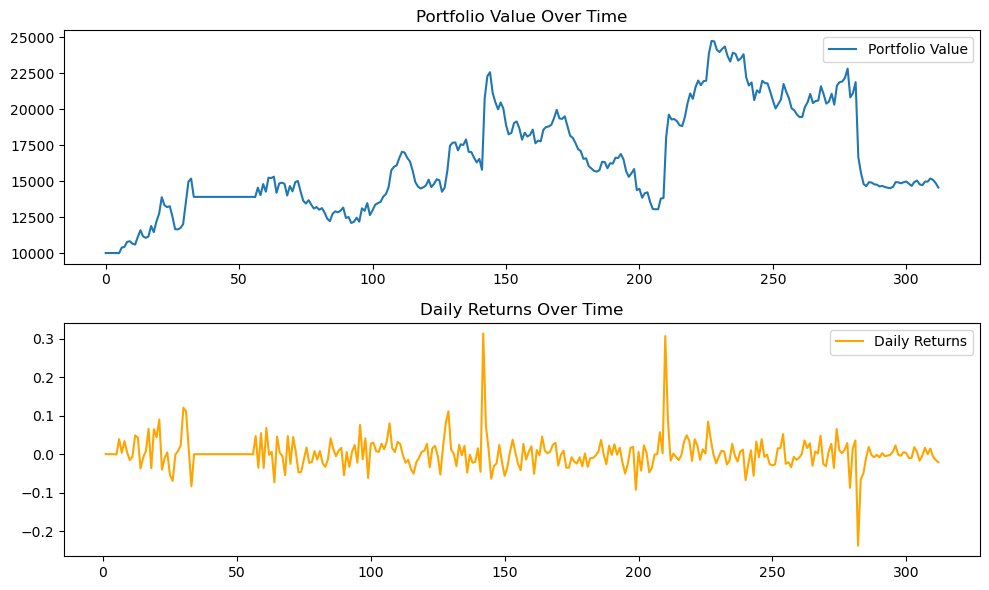

In [190]:
data = data.rename(columns={"NFLX":'close_NFLX','ROKU':'close'})

### if one stock has move 5% of more than the other one over the fours of the last 5 days
### sell the top one and buy the bottom one until it reverses
strategy = Strategy(
    indicators={
        "day_5_lookback_NFLX": lambda df: df["close_NFLX"].shift(5),
        "day_5_lookback_ROKU": lambda df: df["close"].shift(5),
    },
    signal_logic=lambda row: (
        1
        if (row["close_NFLX"] / row["day_5_lookback_NFLX"] > 1.05 and
            row["close"] / row["day_5_lookback_NFLX"] < 0.95)
        else -1 if (row["close"] / row["day_5_lookback_ROKU"] > 1.05 and 
                    row["close_NFLX"] / row["day_5_lookback_NFLX"] < 0.95) 
        else 0

    ),
)

# 1 if Netflix price is greater than 1.05% of the Netflix price 5 days in the future 
# else -1 if Netflix price is lass than Netflix price in the future
# else 0
data = strategy.generate_signals(data)

backtester = Backtester()
backtester.backtest(data)
backtester.calculate_performance()